Step 1. Import libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set(style='whitegrid')

Step 2. Load Iris dataset

In [ ]:
from sklearn.datasets import load_iris

# loading dataset
iris = load_iris()

# using pandas to convert feature data into pandas DataFrame. as result we
# should have 4 columns - sepal/petal length/width
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# adding species column
df['species'] = iris.target

# converting species from 0,1,2 into names
df['species'] = df['species'].map(dict(zip(range(3), iris.target_names)))

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Step 3. Data Analysis

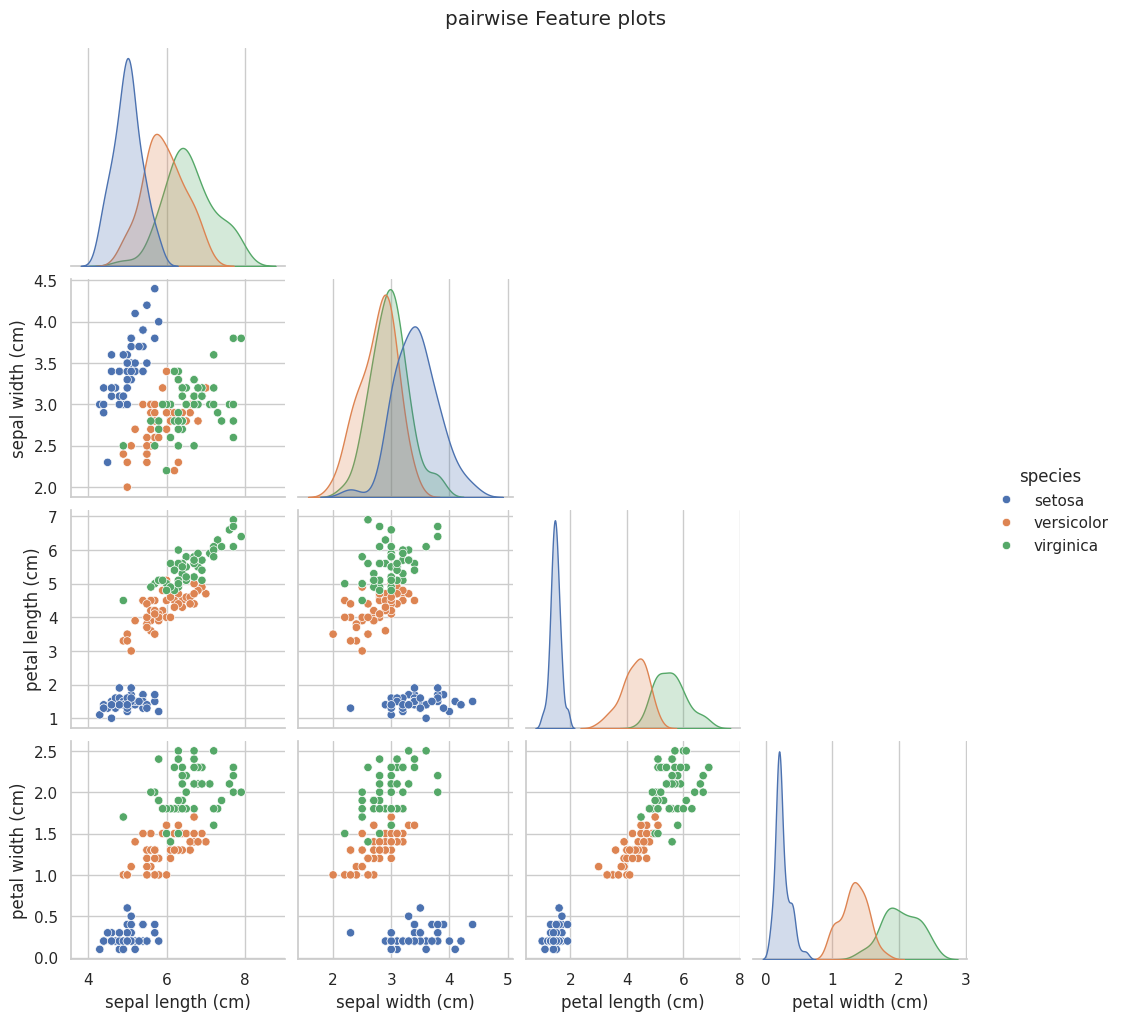

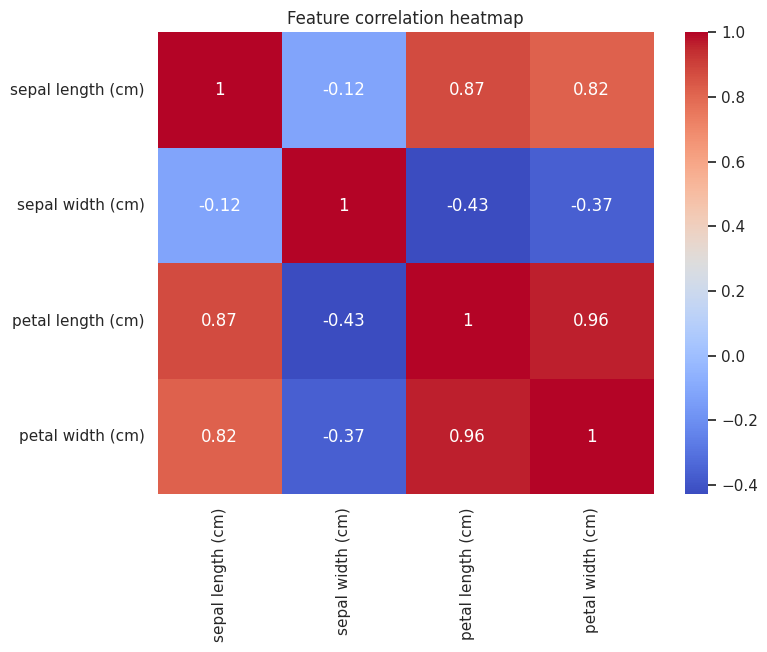

In [ ]:
sns.pairplot(data=df, hue='species', corner=True)
plt.suptitle('pairwise Feature plots', y=1.02)
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.drop('species', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Feature correlation heatmap')
plt.show()

Step 4. Data preprocessing

In [ ]:
X = df.drop('species', axis=1)
y = df['species']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Step 5. Model Training (Logistic Regression)

In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

Step 6. Model Evaluation

Classification Report: 
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Accuracy:  1.0


<function matplotlib.pyplot.show(close=None, block=None)>

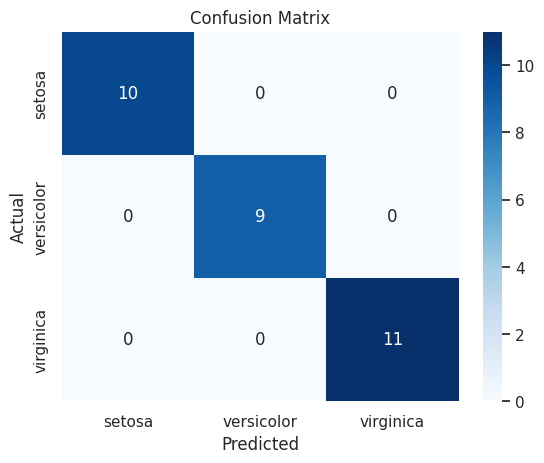

In [ ]:
y_pred = model.predict(X_test_scaled)
print("Classification Report: \n", classification_report(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))

# confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=iris.target_names, yticklabels=iris.target_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show

Step 7. Predict on a new data

In [ ]:
sample = np.array([[3.5, 3.1, 6.2, 6.4]])
sample_scaled = scaler.transform(sample)
prediction = model.predict(sample_scaled)

print("Predicted Iris Species:", prediction[0])


Predicted Iris Species: virginica


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
